# Induction Air Preheater Analysis

## Master's Thesis

### Author
Alberto Maso

---

This notebook contains all the numerical analyses performed on the induction air preheater model.

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

from design import design_preheater
from materials import MATERIALS

# 1. Base Case

Reference operating conditions.

In [22]:
base = design_preheater(
    air_mass_flow=1.5,
    outlet_temperature=400
)

base

{'air_mass_flow': 1.5,
 'air_density': 0.7269613517714505,
 'volume_flow': 2.063383419689119,
 'air_velocity': 15.0,
 'duct_area': 0.13755889464594126,
 'duct_diameter': 0.41850379256736786,
 'material': 'AISI310',
 'tube_thickness': 0.003,
 'outer_diameter': 0.42450379256736787,
 'internal_surface': 39.44305320687329,
 'external_surface': 40.00853988451945,
 'thermal_conductivity': 14.2,
 'max_material_temperature': 1100,
 'emissivity': 0.72,
 'delta_T': 375,
 'thermal_power_kw': 576.140625,
 'electric_power_kw': 2334.761723467277,
 'heated_length': 30.0,
 'heated_volume': 4.126766839378238,
 'residence_time': 2.0,
 'reynolds': 177076.1041986432,
 'flow_regime': 'Turbulent',
 'cp_air': 1024.25,
 'air_conductivity': 0.0399375,
 'air_viscosity': 2.577163791888275e-05,
 'prandtl': 0.71,
 'nusselt': 316.7810123767859,
 'heat_transfer_coefficient': 30.230172119076663,
 'wall_temperature': 695.6893507532295,
 'material_ok': True,
 'insulation': 'RockWool',
 'insulation_k': 0.045,
 'insulati

In [23]:
base_df = pd.DataFrame(
    base.items(),
    columns=["Parameter", "Value"]
)

base_df

,Parameter,Value
0,air_mass_flow,1.5
1,air_density,0.726961
2,volume_flow,2.063383
3,air_velocity,15.0
4,duct_area,0.137559
5,duct_diameter,0.418504
6,material,AISI310
7,tube_thickness,0.003
8,outer_diameter,0.424504
9,internal_surface,39.443053


In [24]:
base_df.to_excel(
    "results/tables/base_case.xlsx",
    index=False
)

# 2. Temperature Sensitivity

Study of the effect of outlet air temperature on the preheater performance.

In [25]:
temperatures = range(250, 601, 25)

results_temperature = []

for T in temperatures:

    results_temperature.append(
        design_preheater(
            air_mass_flow=1.5,
            outlet_temperature=T
        )
    )

df_temperature = pd.DataFrame(results_temperature)

df_temperature

,air_mass_flow,air_density,volume_flow,air_velocity,duct_area,duct_diameter,material,tube_thickness,outer_diameter,internal_surface,...,convection_losses_kw,total_losses_kw,required_induction_power_kw,conduction_resistance,outer_wall_temperature,insulation_resistance,outer_insulation_temperature,pressure_drop_pa,fan_power_kw,total_electric_power_kw
0,1.5,0.859732,1.744731,15.0,0.116315,0.384834,AISI310,0.003,0.390834,36.269765,...,117.763704,458.361744,801.514869,0.000006,424.629764,0.026859,-8791.993976,226.195680,0.526201,844.226063
1,1.5,0.834335,1.797839,15.0,0.119856,0.390647,AISI310,0.003,0.396647,36.817645,...,133.076118,581.034297,962.784297,0.000006,469.973821,0.026506,-9648.726506,216.247218,0.518370,1013.975526
2,1.5,0.810395,1.850948,15.0,0.123397,0.396375,AISI310,0.003,0.402375,37.357490,...,148.798981,728.261515,1148.702140,0.000006,515.464471,0.026168,-10486.496656,207.007208,0.510879,1209.671026
3,1.5,0.787792,1.904057,15.0,0.126937,0.402022,AISI310,0.003,0.408022,37.889644,...,164.924563,903.744236,1362.969236,0.000006,561.094140,0.025843,-11306.428130,198.406979,0.503704,1435.208163
4,1.5,0.766414,1.957166,15.0,0.130478,0.407590,AISI310,0.003,0.413590,38.414428,...,181.445604,1111.521664,1609.624789,0.000005,606.856089,0.025530,-12109.548616,190.386186,0.496823,1694.838706
5,1.5,0.746167,2.010275,15.0,0.134018,0.413083,AISI310,0.003,0.419083,38.932138,...,198.355270,1355.983666,1893.058666,0.000005,652.744303,0.025228,-12896.800382,182.891608,0.490216,1993.183549
6,1.5,0.726961,2.063383,15.0,0.137559,0.418504,AISI310,0.003,0.424504,39.443053,...,215.647119,1641.883012,2218.023637,0.000005,698.753403,0.024938,-13669.049465,175.876153,0.483867,2335.245590
7,1.5,0.708720,2.116492,15.0,0.141099,0.423855,AISI310,0.003,0.429855,39.947435,...,233.315071,1974.347584,2589.647584,0.000005,744.878568,0.024658,-14427.093654,169.298006,0.477757,2726.422582
8,1.5,0.691371,2.169601,15.0,0.144640,0.429140,AISI310,0.003,0.435140,40.445527,...,251.353375,2358.892541,3013.445666,0.000005,791.115470,0.024387,-15171.669463,163.119936,0.471874,3172.519943
9,1.5,0.674852,2.222710,15.0,0.148181,0.434361,AISI310,0.003,0.440361,40.937559,...,269.756587,2801.432483,3495.332483,0.000005,837.460214,0.024126,-15903.458232,157.308685,0.466202,3679.763553


# 3. Air Velocity Sensitivity

Study of the influence of air velocity on the induction preheater performance.

In [3]:
velocities = range(5, 31, 2)

results_velocity = []

for v in velocities:

    data = design_preheater(
        air_mass_flow=1.5,
        outlet_temperature=400,
        air_velocity=v
    )

    results_velocity.append(data)

df_velocity = pd.DataFrame(results_velocity)

df_velocity

,air_mass_flow,air_density,volume_flow,air_velocity,duct_area,duct_diameter,material,tube_thickness,outer_diameter,internal_surface,...,convection_losses_kw,total_losses_kw,required_induction_power_kw,conduction_resistance,outer_wall_temperature,insulation_resistance,outer_insulation_temperature,pressure_drop_pa,fan_power_kw,total_electric_power_kw
0,1.5,0.726961,2.063383,5,0.412677,0.724870,AISI310,0.003,0.730870,22.772457,...,448.625576,52905.338772,53481.479397,0.000009,2467.328813,0.045355,-23663.432566,3.760820,0.010347,56296.304449
1,1.5,0.726961,2.063383,7,0.294769,0.612627,AISI310,0.003,0.618627,26.944735,...,347.497835,14516.058396,15092.199021,0.000008,1621.450515,0.037854,-20187.551371,12.210422,0.033593,15886.558878
2,1.5,0.726961,2.063383,9,0.229265,0.540286,AISI310,0.003,0.546286,30.552458,...,291.456296,6227.511345,6803.651970,0.000007,1204.345212,0.033029,-17825.266826,29.426346,0.080957,7161.819873
3,1.5,0.726961,2.063383,11,0.187580,0.488707,AISI310,0.003,0.494707,33.777013,...,256.302927,3456.779362,4032.919987,0.000006,962.007022,0.029597,-16089.965006,59.396650,0.163411,4245.342345
4,1.5,0.726961,2.063383,13,0.158722,0.449545,AISI310,0.003,0.455545,36.719484,...,232.533969,2257.011764,2833.152389,0.000006,806.163125,0.026996,-14747.220836,106.583330,0.293230,2982.558902
5,1.5,0.726961,2.063383,15,0.137559,0.418504,AISI310,0.003,0.424504,39.443053,...,215.647119,1641.883012,2218.023637,0.000005,698.753403,0.024938,-13669.049465,175.876153,0.483867,2335.245590
6,1.5,0.726961,2.063383,17,0.121375,0.393116,AISI310,0.003,0.399116,41.990337,...,203.231873,1287.275735,1863.416360,0.000005,620.900920,0.023258,-12779.036850,272.557900,0.749855,1962.240760
7,1.5,0.726961,2.063383,19,0.108599,0.371850,AISI310,0.003,0.377850,44.391692,...,193.880748,1064.746652,1640.887277,0.000005,562.268488,0.021853,-12028.419369,402.276954,1.106735,1728.356501
8,1.5,0.726961,2.063383,21,0.098256,0.353700,AISI310,0.003,0.359700,46.669650,...,186.716824,915.962981,1492.103606,0.000004,516.760396,0.020657,-11384.439195,571.024946,1.570991,1572.206366
9,1.5,0.726961,2.063383,23,0.089712,0.337972,AISI310,0.003,0.343972,48.841480,...,181.165470,811.542596,1387.683221,0.000004,480.569101,0.019622,-10824.174775,785.118075,2.159999,1462.879180


In [26]:
df_velocity.to_excel(
    "results/tables/velocity_study.xlsx",
    index=False
)

# 4. Mass Flow Sensitivity

Study of the influence of air mass flow rate on the induction preheater performance.

In [27]:
mass_flows = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

results_mass_flow = []

for m in mass_flows:

    data = design_preheater(
        air_mass_flow=m,
        outlet_temperature=400,
        air_velocity=15
    )

    results_mass_flow.append(data)

df_mass_flow = pd.DataFrame(results_mass_flow)

df_mass_flow

,air_mass_flow,air_density,volume_flow,air_velocity,duct_area,duct_diameter,material,tube_thickness,outer_diameter,internal_surface,...,convection_losses_kw,total_losses_kw,required_induction_power_kw,conduction_resistance,outer_wall_temperature,insulation_resistance,outer_insulation_temperature,pressure_drop_pa,fan_power_kw,total_electric_power_kw
0,0.5,0.726961,0.687794,15,0.045853,0.241623,AISI310,0.003,0.247623,22.772457,...,82.001135,353.444938,545.491813,0.000009,464.205005,0.039990,-7215.831604,304.626432,0.279361,574.481269
1,1.0,0.726961,1.375589,15,0.091706,0.341707,AISI310,0.003,0.347707,32.205118,...,149.130822,885.833559,1269.927309,0.000007,593.843720,0.029801,-10852.437058,215.403416,0.395075,1337.160664
2,1.5,0.726961,2.063383,15,0.137559,0.418504,AISI310,0.003,0.424504,39.443053,...,215.647119,1641.883012,2218.023637,0.000005,698.753403,0.024938,-13669.049465,175.876153,0.483867,2335.245590
3,2.0,0.726961,2.751178,15,0.183412,0.483247,AISI310,0.003,0.489247,45.544915,...,282.293205,2642.936168,3411.123668,0.000005,790.264441,0.021925,-16052.581542,152.313216,0.558721,3591.215213
4,2.5,0.726961,3.438972,15,0.229265,0.540286,AISI310,0.003,0.546286,50.920763,...,349.262006,3909.573081,4869.807456,0.000004,872.949719,0.019818,-18156.662318,136.233082,0.624669,5126.737781
5,3.0,0.726961,4.126767,15,0.275118,0.591854,AISI310,0.003,0.597854,55.780901,...,416.611820,5461.802300,6614.083550,0.000004,949.220343,0.018234,-20061.086924,124.363220,0.684291,6962.877501


In [28]:
df_mass_flow.to_excel(
    "results/tables/mass_flow_study.xlsx",
    index=False
)

# 5. Material Comparison

Comparison of different tube materials for the induction preheater.

In [29]:
materials = [
    "AISI304",
    "AISI310"
]

results_materials = []

for material in materials:

    data = design_preheater(
        air_mass_flow=1.5,
        outlet_temperature=400,
        air_velocity=15,
        material=material
    )

    results_materials.append(data)

df_materials = pd.DataFrame(results_materials)

df_materials

,air_mass_flow,air_density,volume_flow,air_velocity,duct_area,duct_diameter,material,tube_thickness,outer_diameter,internal_surface,...,convection_losses_kw,total_losses_kw,required_induction_power_kw,conduction_resistance,outer_wall_temperature,insulation_resistance,outer_insulation_temperature,pressure_drop_pa,fan_power_kw,total_electric_power_kw
0,1.5,0.726961,2.063383,15,0.137559,0.418504,AISI304,0.003,0.424504,39.443053,...,215.526044,1503.100115,2079.240740,0.000005,698.375125,0.024938,-13669.427743,175.876153,0.483867,2189.158329
1,1.5,0.726961,2.063383,15,0.137559,0.418504,AISI310,0.003,0.424504,39.443053,...,215.647119,1641.883012,2218.023637,0.000005,698.753403,0.024938,-13669.049465,175.876153,0.483867,2335.245590


In [30]:
df_materials.to_excel(
    "results/tables/material_comparison.xlsx",
    index=False
)

# 6. Summary of Parametric Studies

The following tables summarize the results obtained from the different parametric analyses carried out on the induction preheater model.

In [ ]:
df_temperature.to_excel(
    "results/tables/temperature_study.xlsx",
    index=False
)

df_velocity.to_excel(
    "results/tables/velocity_study.xlsx",
    index=False
)

df_mass_flow.to_excel(
    "results/tables/mass_flow_study.xlsx",
    index=False
)

df_materials.to_excel(
    "results/tables/material_comparison.xlsx",
    index=False
)

print("All tables saved successfully.")plt.figure(figsize=(8,5))

plt.plot(
    df_temperature["outlet_temperature"],
    df_temperature["total_electric_power_kw"],
    marker="o",
    linewidth=2
)

plt.xlabel("Outlet Temperature [°C]")
plt.ylabel("Total Electric Power [kW]")
plt.title("Total Electric Power vs Outlet Temperature")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "results/figures/total_electric_power_vs_temperature.png",
    dpi=300
)

plt.show()

All tables saved successfully.


# 7. Results Visualization

The following figures illustrate the influence of the main design parameters on the performance of the induction preheater.

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    df_temperature["outlet_temperature"],
    df_temperature["total_electric_power_kw"],
    marker="o",
    linewidth=2
)

plt.xlabel("Outlet Temperature [°C]")
plt.ylabel("Total Electric Power [kW]")
plt.title("Total Electric Power vs Outlet Temperature")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "results/figures/total_electric_power_vs_temperature.png",
    dpi=300
)

plt.show()

KeyError: 'outlet_temperature'

<Figure size 800x500 with 0 Axes>

In [34]:
print(df_temperature.columns.tolist())

['air_mass_flow', 'air_density', 'volume_flow', 'air_velocity', 'duct_area', 'duct_diameter', 'material', 'tube_thickness', 'outer_diameter', 'internal_surface', 'external_surface', 'thermal_conductivity', 'max_material_temperature', 'emissivity', 'delta_T', 'thermal_power_kw', 'electric_power_kw', 'heated_length', 'heated_volume', 'residence_time', 'reynolds', 'flow_regime', 'cp_air', 'air_conductivity', 'air_viscosity', 'prandtl', 'nusselt', 'heat_transfer_coefficient', 'wall_temperature', 'material_ok', 'insulation', 'insulation_k', 'insulation_max_temperature', 'insulation_outer_diameter', 'insulation_external_surface', 'radiation_losses_kw', 'convection_losses_kw', 'total_losses_kw', 'required_induction_power_kw', 'conduction_resistance', 'outer_wall_temperature', 'insulation_resistance', 'outer_insulation_temperature', 'pressure_drop_pa', 'fan_power_kw', 'total_electric_power_kw']


In [35]:
temperatures = range(250, 601, 25)

results_temperature = []

for T in temperatures:
    results_temperature.append(
        design_preheater(
            air_mass_flow=1.5,
            outlet_temperature=T
        )
    )

df_temperature = pd.DataFrame(results_temperature)

print(df_temperature.columns.tolist())

['air_mass_flow', 'air_density', 'volume_flow', 'air_velocity', 'duct_area', 'duct_diameter', 'material', 'tube_thickness', 'outer_diameter', 'internal_surface', 'external_surface', 'thermal_conductivity', 'max_material_temperature', 'emissivity', 'delta_T', 'thermal_power_kw', 'electric_power_kw', 'heated_length', 'heated_volume', 'residence_time', 'reynolds', 'flow_regime', 'cp_air', 'air_conductivity', 'air_viscosity', 'prandtl', 'nusselt', 'heat_transfer_coefficient', 'wall_temperature', 'material_ok', 'insulation', 'insulation_k', 'insulation_max_temperature', 'insulation_outer_diameter', 'insulation_external_surface', 'radiation_losses_kw', 'convection_losses_kw', 'total_losses_kw', 'required_induction_power_kw', 'conduction_resistance', 'outer_wall_temperature', 'insulation_resistance', 'outer_insulation_temperature', 'pressure_drop_pa', 'fan_power_kw', 'total_electric_power_kw']


In [36]:
import inspect

print(inspect.getfile(design_preheater))

c:\Users\alber\Desktop\HES_1\preheater\design.py


In [37]:
import inspect

print(inspect.getsource(design_preheater))

def design_preheater(
    air_mass_flow,
    outlet_temperature,
    air_velocity=15.0,
    material=DEFAULT_MATERIAL,
    insulation="RockWool"
):

    # ----------------------------------------------------------
    # Material properties
    # ----------------------------------------------------------

    material_data = MATERIALS[material]

    thermal_conductivity = material_data["thermal_conductivity"]

    max_temperature = material_data["max_temperature"]

    emissivity = material_data["emissivity"]

    # ----------------------------------------------------------
    # Insulation properties
    # ----------------------------------------------------------

    insulation_data = INSULATIONS[insulation]

    insulation_k = insulation_data["k"]

    insulation_max_temperature = insulation_data["max_temperature"]

    # ----------------------------------------------------------
    # Temperature rise
    # ----------------------------------------------------------

    delta_T = o

In [38]:
test = design_preheater(
    air_mass_flow=1.5,
    outlet_temperature=400
)

print(test.keys())

dict_keys(['air_mass_flow', 'air_density', 'volume_flow', 'air_velocity', 'duct_area', 'duct_diameter', 'material', 'tube_thickness', 'outer_diameter', 'internal_surface', 'external_surface', 'thermal_conductivity', 'max_material_temperature', 'emissivity', 'delta_T', 'thermal_power_kw', 'electric_power_kw', 'heated_length', 'heated_volume', 'residence_time', 'reynolds', 'flow_regime', 'cp_air', 'air_conductivity', 'air_viscosity', 'prandtl', 'nusselt', 'heat_transfer_coefficient', 'wall_temperature', 'material_ok', 'insulation', 'insulation_k', 'insulation_max_temperature', 'insulation_outer_diameter', 'insulation_external_surface', 'radiation_losses_kw', 'convection_losses_kw', 'total_losses_kw', 'required_induction_power_kw', 'conduction_resistance', 'outer_wall_temperature', 'insulation_resistance', 'outer_insulation_temperature', 'pressure_drop_pa', 'fan_power_kw', 'total_electric_power_kw'])


In [39]:
import inspect

print(inspect.getfile(design_preheater))

c:\Users\alber\Desktop\HES_1\preheater\design.py


In [40]:
print(inspect.getsource(design_preheater)[-800:])

ax_temperature": insulation_max_temperature,

        "insulation_outer_diameter": insulation_outer_diameter,

        "insulation_external_surface": insulation_external_surface,

        "radiation_losses_kw": radiation_losses_kw,

        "convection_losses_kw": convection_losses_kw,

        "total_losses_kw": total_losses_kw,

        "required_induction_power_kw": required_induction_power_kw,

        "conduction_resistance": conduction_resistance,

        "outer_wall_temperature": outer_wall_temperature,

#        "insulation_resistance": insulation_resistance,

#        "outer_insulation_temperature": outer_insulation_temperature,

        "pressure_drop_pa": pressure_drop_pa,

        "fan_power_kw": fan_power_kw,

        "total_electric_power_kw": total_electric_power_kw,
    }



In [42]:
import inspect
import design

print("File:", inspect.getfile(design_preheater))
print("Design module:", design.__file__)

File: c:\Users\alber\Desktop\HES_1\preheater\design.py
Design module: c:\Users\alber\Desktop\HES_1\preheater\design.py


In [43]:
import importlib
import design

importlib.reload(design)

from design import design_preheater

test = design_preheater(
    air_mass_flow=1.5,
    outlet_temperature=400
)

print(test.keys())

dict_keys(['air_mass_flow', 'air_density', 'volume_flow', 'air_velocity', 'duct_area', 'duct_diameter', 'material', 'tube_thickness', 'outer_diameter', 'internal_surface', 'external_surface', 'thermal_conductivity', 'max_material_temperature', 'emissivity', 'delta_T', 'outlet_temperature', 'thermal_power_kw', 'electric_power_kw', 'heated_length', 'heated_volume', 'residence_time', 'reynolds', 'flow_regime', 'cp_air', 'air_conductivity', 'air_viscosity', 'prandtl', 'nusselt', 'heat_transfer_coefficient', 'wall_temperature', 'material_ok', 'insulation', 'insulation_k', 'insulation_max_temperature', 'insulation_outer_diameter', 'insulation_external_surface', 'radiation_losses_kw', 'convection_losses_kw', 'total_losses_kw', 'required_induction_power_kw', 'conduction_resistance', 'outer_wall_temperature', 'pressure_drop_pa', 'fan_power_kw', 'total_electric_power_kw'])


In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    df_temperature["outlet_temperature"],
    df_temperature["total_electric_power_kw"],
    marker="o"
)

plt.xlabel("Outlet Temperature (°C)")
plt.ylabel("Total Electric Power (kW)")
plt.title("Effect of Outlet Temperature on Total Electric Power")
plt.grid(True)

plt.show()

KeyError: 'outlet_temperature'

<Figure size 800x500 with 0 Axes>

In [46]:
print(df_temperature.columns.tolist())

['air_mass_flow', 'air_density', 'volume_flow', 'air_velocity', 'duct_area', 'duct_diameter', 'material', 'tube_thickness', 'outer_diameter', 'internal_surface', 'external_surface', 'thermal_conductivity', 'max_material_temperature', 'emissivity', 'delta_T', 'thermal_power_kw', 'electric_power_kw', 'heated_length', 'heated_volume', 'residence_time', 'reynolds', 'flow_regime', 'cp_air', 'air_conductivity', 'air_viscosity', 'prandtl', 'nusselt', 'heat_transfer_coefficient', 'wall_temperature', 'material_ok', 'insulation', 'insulation_k', 'insulation_max_temperature', 'insulation_outer_diameter', 'insulation_external_surface', 'radiation_losses_kw', 'convection_losses_kw', 'total_losses_kw', 'required_induction_power_kw', 'conduction_resistance', 'outer_wall_temperature', 'insulation_resistance', 'outer_insulation_temperature', 'pressure_drop_pa', 'fan_power_kw', 'total_electric_power_kw']


In [49]:
print(df_temperature.columns.tolist())

['air_mass_flow', 'air_density', 'volume_flow', 'air_velocity', 'duct_area', 'duct_diameter', 'material', 'tube_thickness', 'outer_diameter', 'internal_surface', 'external_surface', 'thermal_conductivity', 'max_material_temperature', 'emissivity', 'delta_T', 'thermal_power_kw', 'electric_power_kw', 'heated_length', 'heated_volume', 'residence_time', 'reynolds', 'flow_regime', 'cp_air', 'air_conductivity', 'air_viscosity', 'prandtl', 'nusselt', 'heat_transfer_coefficient', 'wall_temperature', 'material_ok', 'insulation', 'insulation_k', 'insulation_max_temperature', 'insulation_outer_diameter', 'insulation_external_surface', 'radiation_losses_kw', 'convection_losses_kw', 'total_losses_kw', 'required_induction_power_kw', 'conduction_resistance', 'outer_wall_temperature', 'insulation_resistance', 'outer_insulation_temperature', 'pressure_drop_pa', 'fan_power_kw', 'total_electric_power_kw']


In [50]:
temperatures = range(250, 601, 25)

results_temperature = []

for T in temperatures:
    data = design_preheater(
        air_mass_flow=1.5,
        outlet_temperature=T
    )
    results_temperature.append(data)

df_temperature = pd.DataFrame(results_temperature)

print(df_temperature.columns.tolist())

['air_mass_flow', 'air_density', 'volume_flow', 'air_velocity', 'duct_area', 'duct_diameter', 'material', 'tube_thickness', 'outer_diameter', 'internal_surface', 'external_surface', 'thermal_conductivity', 'max_material_temperature', 'emissivity', 'delta_T', 'outlet_temperature', 'thermal_power_kw', 'electric_power_kw', 'heated_length', 'heated_volume', 'residence_time', 'reynolds', 'flow_regime', 'cp_air', 'air_conductivity', 'air_viscosity', 'prandtl', 'nusselt', 'heat_transfer_coefficient', 'wall_temperature', 'material_ok', 'insulation', 'insulation_k', 'insulation_max_temperature', 'insulation_outer_diameter', 'insulation_external_surface', 'radiation_losses_kw', 'convection_losses_kw', 'total_losses_kw', 'required_induction_power_kw', 'conduction_resistance', 'outer_wall_temperature', 'pressure_drop_pa', 'fan_power_kw', 'total_electric_power_kw']


In [51]:
print(df_temperature.columns.tolist())

['air_mass_flow', 'air_density', 'volume_flow', 'air_velocity', 'duct_area', 'duct_diameter', 'material', 'tube_thickness', 'outer_diameter', 'internal_surface', 'external_surface', 'thermal_conductivity', 'max_material_temperature', 'emissivity', 'delta_T', 'outlet_temperature', 'thermal_power_kw', 'electric_power_kw', 'heated_length', 'heated_volume', 'residence_time', 'reynolds', 'flow_regime', 'cp_air', 'air_conductivity', 'air_viscosity', 'prandtl', 'nusselt', 'heat_transfer_coefficient', 'wall_temperature', 'material_ok', 'insulation', 'insulation_k', 'insulation_max_temperature', 'insulation_outer_diameter', 'insulation_external_surface', 'radiation_losses_kw', 'convection_losses_kw', 'total_losses_kw', 'required_induction_power_kw', 'conduction_resistance', 'outer_wall_temperature', 'pressure_drop_pa', 'fan_power_kw', 'total_electric_power_kw']


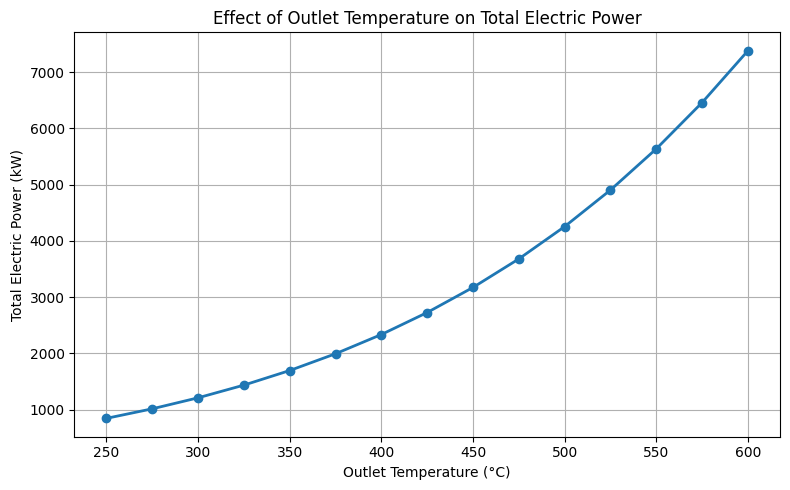

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    df_temperature["outlet_temperature"],
    df_temperature["total_electric_power_kw"],
    marker="o",
    linewidth=2
)

plt.xlabel("Outlet Temperature (°C)")
plt.ylabel("Total Electric Power (kW)")
plt.title("Effect of Outlet Temperature on Total Electric Power")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "results/figures/temperature_vs_power.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

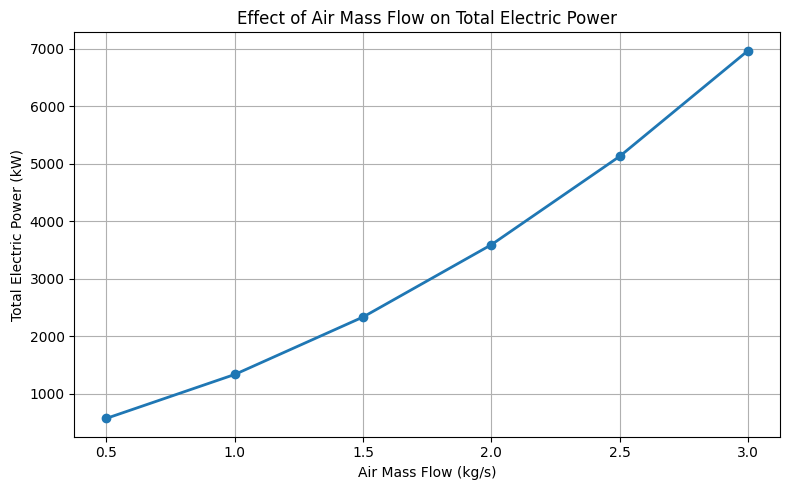

In [54]:
plt.figure(figsize=(8,5))

plt.plot(
    df_mass_flow["air_mass_flow"],
    df_mass_flow["total_electric_power_kw"],
    marker="o",
    linewidth=2
)

plt.xlabel("Air Mass Flow (kg/s)")
plt.ylabel("Total Electric Power (kW)")
plt.title("Effect of Air Mass Flow on Total Electric Power")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "results/figures/massflow_vs_power.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

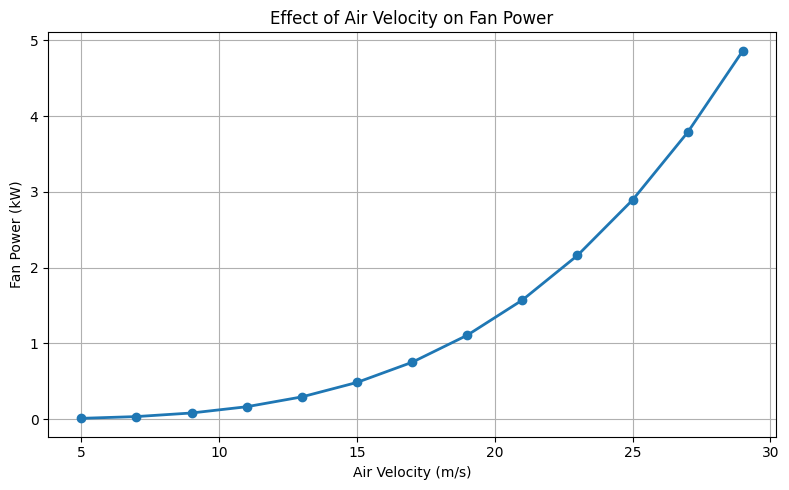

In [55]:
plt.figure(figsize=(8,5))

plt.plot(
    df_velocity["air_velocity"],
    df_velocity["fan_power_kw"],
    marker="o",
    linewidth=2
)

plt.xlabel("Air Velocity (m/s)")
plt.ylabel("Fan Power (kW)")
plt.title("Effect of Air Velocity on Fan Power")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "results/figures/velocity_vs_fanpower.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
materials = list(MATERIALS.keys())

results_materials = []

for material in materials:

    data = design_preheater(
        air_mass_flow=1.5,
        outlet_temperature=400,
        air_velocity=15,
        material=material
    )

    results_materials.append(data)

df_materials = pd.DataFrame(results_materials)

df_materials

,air_mass_flow,air_density,volume_flow,air_velocity,duct_area,duct_diameter,material,tube_thickness,outer_diameter,internal_surface,...,insulation_external_surface,radiation_losses_kw,convection_losses_kw,total_losses_kw,required_induction_power_kw,conduction_resistance,outer_wall_temperature,pressure_drop_pa,fan_power_kw,total_electric_power_kw
0,1.5,0.726961,2.063383,15,0.137559,0.418504,AISI304,0.003,0.424504,39.443053,...,49.433318,1287.574070,215.526044,1503.100115,2079.240740,0.000005,698.375125,175.876153,0.483867,2189.158329
1,1.5,0.726961,2.063383,15,0.137559,0.418504,AISI310,0.003,0.424504,39.443053,...,49.433318,1426.235893,215.647119,1641.883012,2218.023637,0.000005,698.753403,175.876153,0.483867,2335.245590


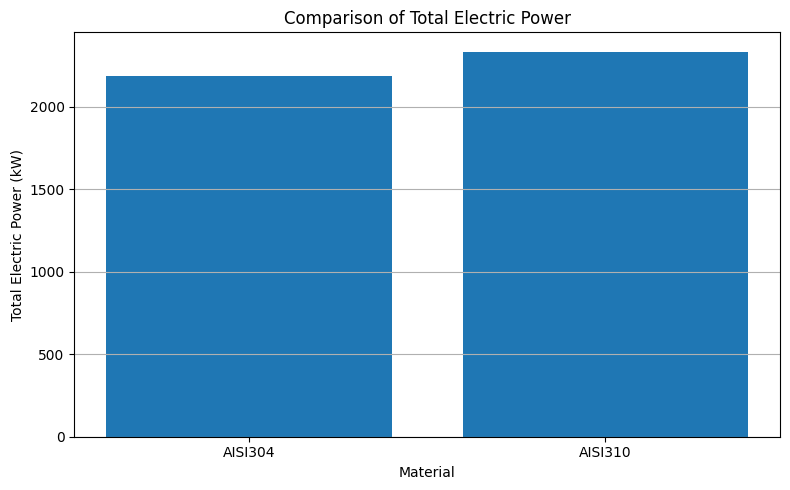

In [63]:
plt.figure(figsize=(8,5))

plt.bar(
    df_materials["material"],
    df_materials["total_electric_power_kw"]
)

plt.xlabel("Material")
plt.ylabel("Total Electric Power (kW)")
plt.title("Comparison of Total Electric Power")

plt.grid(axis="y")
plt.tight_layout()

plt.savefig(
    "results/figures/material_power.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
import importlib
import materials

importlib.reload(materials)

from materials import MATERIALS

In [68]:
from materials import MATERIALS

materials_list = list(MATERIALS.keys())

results_materials = []

for material in materials_list:

    data = design_preheater(
        air_mass_flow=1.5,
        outlet_temperature=400,
        air_velocity=15,
        material=material
    )

    results_materials.append(data)

df_materials = pd.DataFrame(results_materials)

df_materials

,air_mass_flow,air_density,volume_flow,air_velocity,duct_area,duct_diameter,material,tube_thickness,outer_diameter,internal_surface,...,insulation_external_surface,radiation_losses_kw,convection_losses_kw,total_losses_kw,required_induction_power_kw,conduction_resistance,outer_wall_temperature,pressure_drop_pa,fan_power_kw,total_electric_power_kw
0,1.5,0.726961,2.063383,15,0.137559,0.418504,AISI304,0.003,0.424504,39.443053,...,49.433318,1287.574070,215.526044,1503.100115,2079.240740,0.000005,698.375125,175.876153,0.483867,2189.158329
1,1.5,0.726961,2.063383,15,0.137559,0.418504,AISI316,0.003,0.424504,39.443053,...,49.433318,1228.147575,215.661129,1443.808704,2019.949329,0.000005,698.797175,175.876153,0.483867,2126.746318
2,1.5,0.726961,2.063383,15,0.137559,0.418504,AISI321,0.003,0.424504,39.443053,...,49.433318,1287.574070,215.520770,1503.094841,2079.235466,0.000005,698.358648,175.876153,0.483867,2189.152778
3,1.5,0.726961,2.063383,15,0.137559,0.418504,AISI310,0.003,0.424504,39.443053,...,49.433318,1426.235893,215.647119,1641.883012,2218.023637,0.000005,698.753403,175.876153,0.483867,2335.245590
4,1.5,0.726961,2.063383,15,0.137559,0.418504,RA330,0.003,0.424504,39.443053,...,49.433318,1485.662389,215.594815,1701.257204,2277.397829,0.000005,698.589987,175.876153,0.483867,2397.744739
5,1.5,0.726961,2.063383,15,0.137559,0.418504,Inconel600,0.003,0.424504,39.443053,...,49.433318,1386.618230,215.601046,1602.219275,2178.359900,0.000005,698.609454,175.876153,0.483867,2293.494288
6,1.5,0.726961,2.063383,15,0.137559,0.418504,Inconel601,0.003,0.424504,39.443053,...,49.433318,1426.235893,215.576611,1641.812504,2217.953129,0.000005,698.533111,175.876153,0.483867,2335.171371
7,1.5,0.726961,2.063383,15,0.137559,0.418504,Inconel625,0.003,0.424504,39.443053,...,49.433318,1347.000566,216.087436,1563.088002,2139.228627,0.000008,700.129100,175.876153,0.483867,2252.303474


In [66]:
from materials import MATERIALS

print(MATERIALS.keys())

dict_keys(['AISI304', 'AISI316', 'AISI321', 'AISI310', 'RA330', 'Inconel600', 'Inconel601', 'Inconel625'])


In [67]:
import importlib
import design

importlib.reload(design)

from design import design_preheater

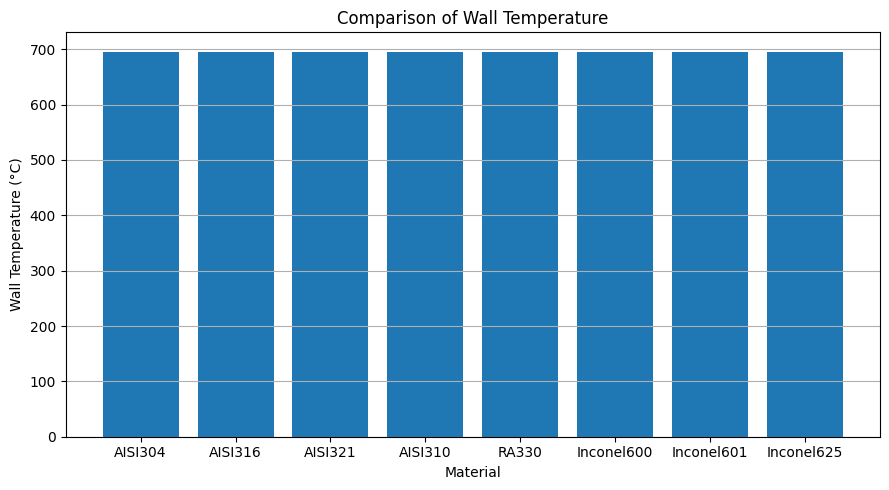

In [69]:
plt.figure(figsize=(9,5))

plt.bar(
    df_materials["material"],
    df_materials["wall_temperature"]
)

plt.xlabel("Material")
plt.ylabel("Wall Temperature (°C)")
plt.title("Comparison of Wall Temperature")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "results/figures/material_wall_temperature.png",
    dpi=300
)

plt.show()

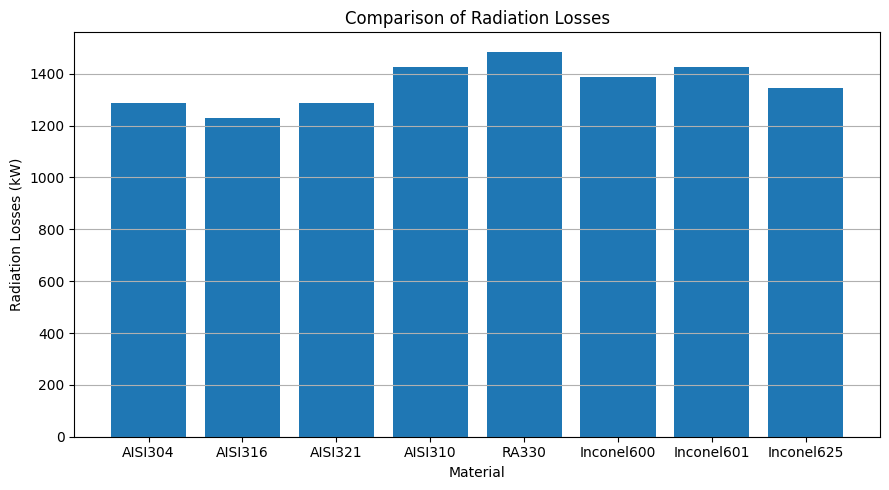

In [70]:
plt.figure(figsize=(9,5))

plt.bar(
    df_materials["material"],
    df_materials["radiation_losses_kw"]
)

plt.xlabel("Material")
plt.ylabel("Radiation Losses (kW)")
plt.title("Comparison of Radiation Losses")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "results/figures/material_radiation_losses.png",
    dpi=300
)

plt.show()

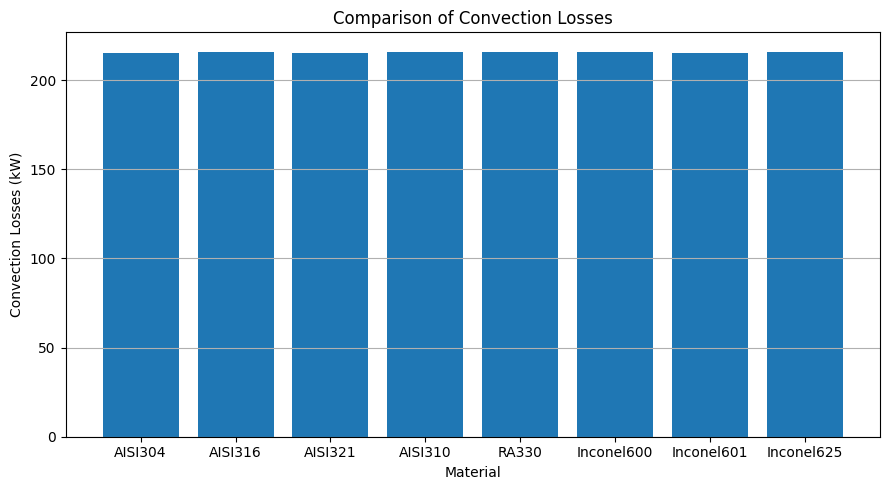

In [71]:
plt.figure(figsize=(9,5))

plt.bar(
    df_materials["material"],
    df_materials["convection_losses_kw"]
)

plt.xlabel("Material")
plt.ylabel("Convection Losses (kW)")
plt.title("Comparison of Convection Losses")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "results/figures/material_convection_losses.png",
    dpi=300
)

plt.show()

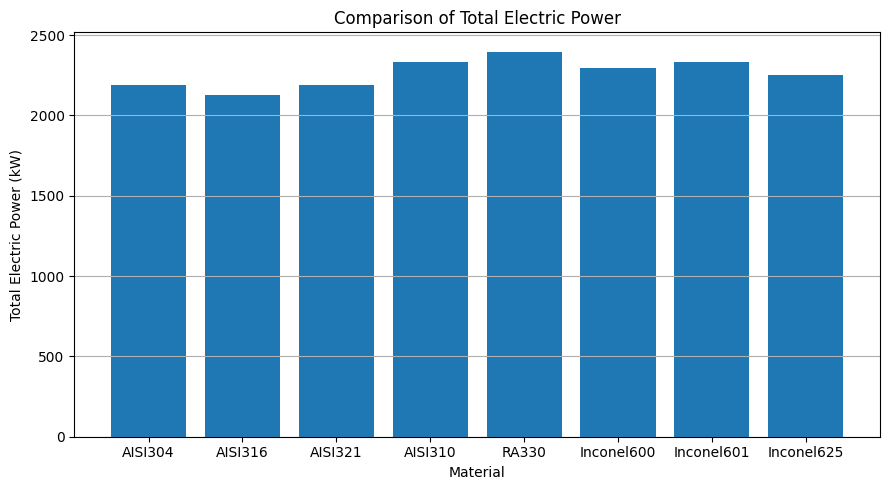

In [72]:
plt.figure(figsize=(9,5))

plt.bar(
    df_materials["material"],
    df_materials["total_electric_power_kw"]
)

plt.xlabel("Material")
plt.ylabel("Total Electric Power (kW)")
plt.title("Comparison of Total Electric Power")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "results/figures/material_total_power.png",
    dpi=300
)

plt.show()

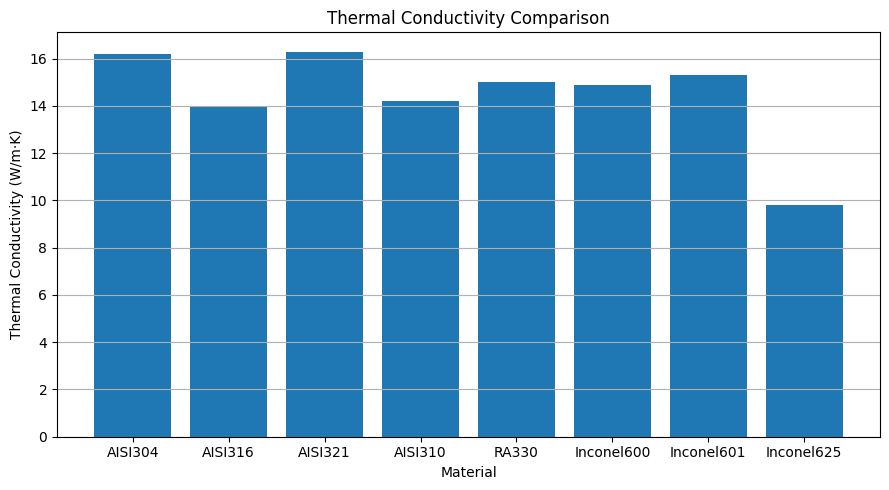

In [73]:
plt.figure(figsize=(9,5))

plt.bar(
    df_materials["material"],
    df_materials["thermal_conductivity"]
)

plt.xlabel("Material")
plt.ylabel("Thermal Conductivity (W/m·K)")
plt.title("Thermal Conductivity Comparison")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "results/figures/material_thermal_conductivity.png",
    dpi=300
)

plt.show()

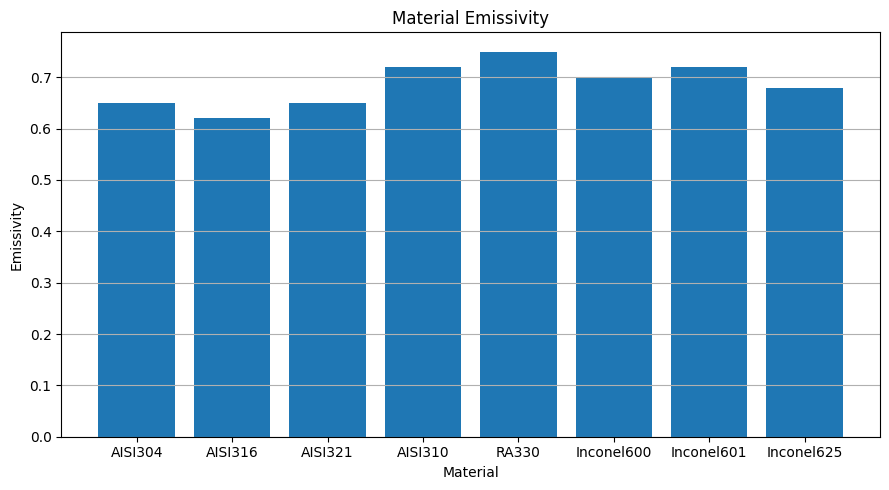

In [74]:
plt.figure(figsize=(9,5))

plt.bar(
    df_materials["material"],
    df_materials["emissivity"]
)

plt.xlabel("Material")
plt.ylabel("Emissivity")
plt.title("Material Emissivity")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "results/figures/material_emissivity.png",
    dpi=300
)

plt.show()

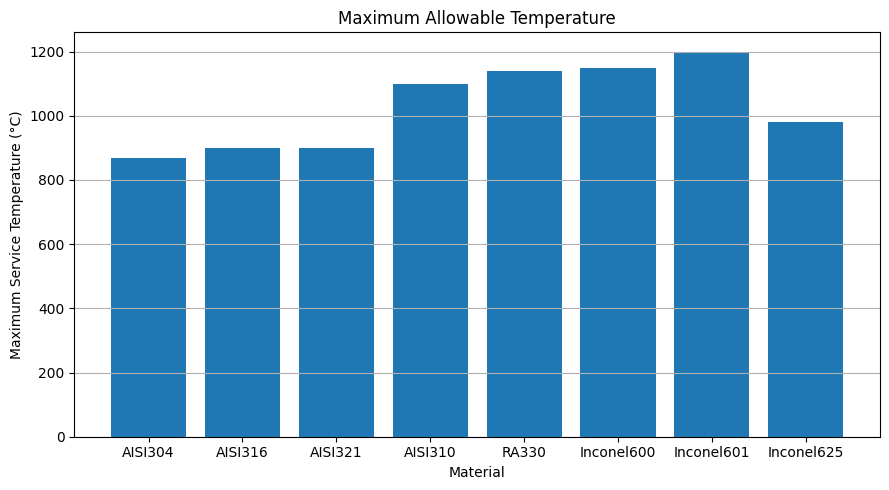

In [75]:
plt.figure(figsize=(9,5))

plt.bar(
    df_materials["material"],
    df_materials["max_material_temperature"]
)

plt.xlabel("Material")
plt.ylabel("Maximum Service Temperature (°C)")
plt.title("Maximum Allowable Temperature")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "results/figures/material_max_temperature.png",
    dpi=300
)

plt.show()

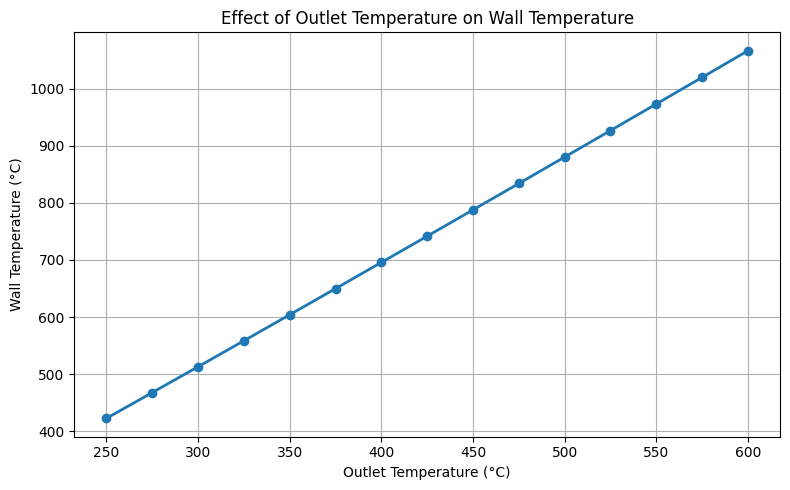

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    df_temperature["outlet_temperature"],
    df_temperature["wall_temperature"],
    marker="o",
    linewidth=2
)

plt.xlabel("Outlet Temperature (°C)")
plt.ylabel("Wall Temperature (°C)")
plt.title("Effect of Outlet Temperature on Wall Temperature")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "results/figures/temperature_vs_wall_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

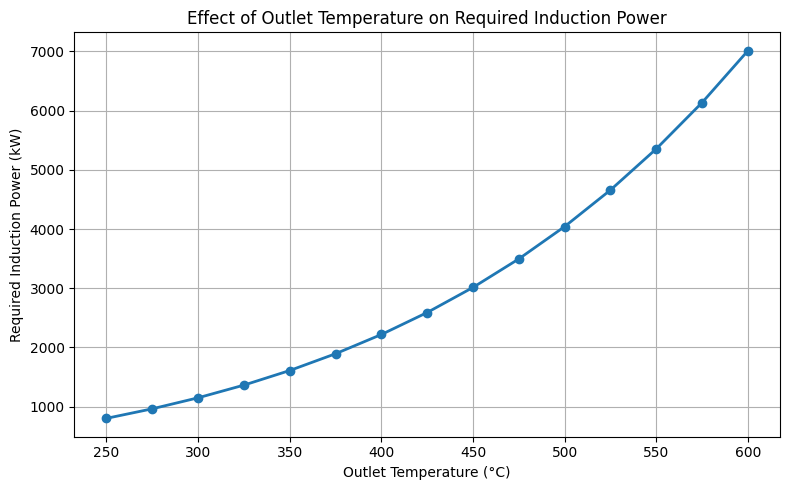

In [77]:
plt.figure(figsize=(8,5))

plt.plot(
    df_temperature["outlet_temperature"],
    df_temperature["required_induction_power_kw"],
    marker="o",
    linewidth=2
)

plt.xlabel("Outlet Temperature (°C)")
plt.ylabel("Required Induction Power (kW)")
plt.title("Effect of Outlet Temperature on Required Induction Power")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "results/figures/temperature_vs_required_power.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

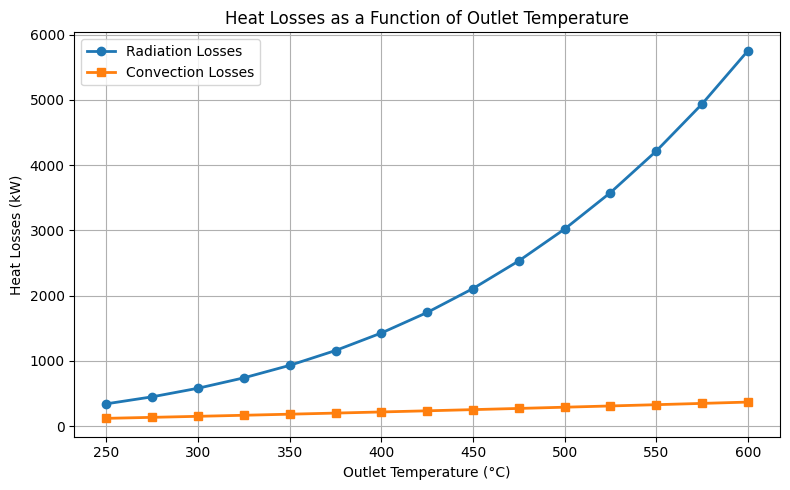

In [78]:
plt.figure(figsize=(8,5))

plt.plot(
    df_temperature["outlet_temperature"],
    df_temperature["radiation_losses_kw"],
    marker="o",
    linewidth=2,
    label="Radiation Losses"
)

plt.plot(
    df_temperature["outlet_temperature"],
    df_temperature["convection_losses_kw"],
    marker="s",
    linewidth=2,
    label="Convection Losses"
)

plt.xlabel("Outlet Temperature (°C)")
plt.ylabel("Heat Losses (kW)")
plt.title("Heat Losses as a Function of Outlet Temperature")

plt.legend()

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "results/figures/radiation_vs_convection_losses.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

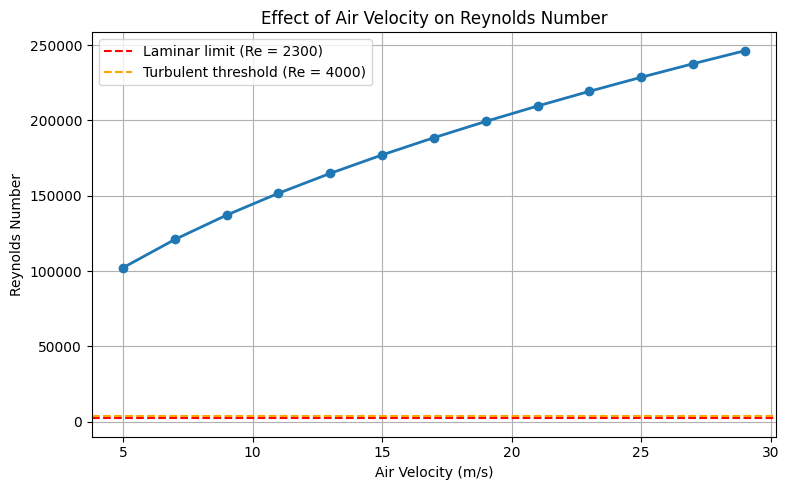

In [79]:
plt.figure(figsize=(8,5))

plt.plot(
    df_velocity["air_velocity"],
    df_velocity["reynolds"],
    marker="o",
    linewidth=2
)

plt.axhline(
    y=2300,
    color="red",
    linestyle="--",
    label="Laminar limit (Re = 2300)"
)

plt.axhline(
    y=4000,
    color="orange",
    linestyle="--",
    label="Turbulent threshold (Re = 4000)"
)

plt.xlabel("Air Velocity (m/s)")
plt.ylabel("Reynolds Number")
plt.title("Effect of Air Velocity on Reynolds Number")

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    "results/figures/reynolds_vs_velocity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()